In [1]:
# Crowd Density Estimation Demo

# Install dependencies
!pip install opencv-python matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img = cv2.imread(r"D:\Projects all\...Crowd_Density_Estimation\data\raw\sample_crowd.jpg")


In [19]:
import os
os.makedirs("data/raw", exist_ok=True)


In [21]:
img = cv2.imread(r"D:\Projects all\All GITHUB PROJECTS TO UPLOAD\Z FOLDERS OF ALL THE MAIN TOPICS\Computer_Vision\Crowd_Density_Estimation\data\raw\sample_crowd.jpg")
if img is None:
    raise FileNotFoundError("Image not found. Please check the path.")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [22]:
corners = cv2.goodFeaturesToTrack(gray, maxCorners=500, qualityLevel=0.01, minDistance=10)

if corners is not None:
    count = len(corners)
    if count < 100:
        density = "Low"
    elif count < 300:
        density = "Medium"
    else:
        density = "High"
else:
    density = "None"

print(f"Estimated crowd density: {density} ({count if corners is not None else 0} features)")


Estimated crowd density: Medium (292 features)


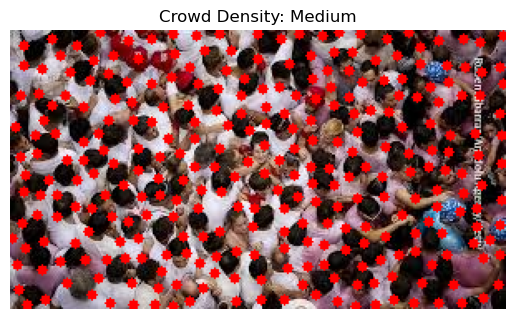

In [23]:
# --- Visualize ---
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(img, (int(x), int(y)), 3, (0, 0, 255), -1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Crowd Density: {density}")
plt.axis("off")
plt.show()